# Exploratory Data Analysis

---
## 1. Setup & Imports

In [1]:
import json
import re
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import nltk
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer

# Download Spanish stopwords (only needed once)
nltk.download("stopwords", quiet=True)
from nltk.corpus import stopwords

SPANISH_STOPWORDS = set(stopwords.words("spanish"))

# Paths — relative to project root
PROJECT_ROOT = Path("__file__").resolve().parent.parent
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
METADATA_FILE = PROCESSED_DIR / "metadata_plaintext.jsonl"

# Plot style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["figure.figsize"] = (10, 5)

print(f"Processed dir: {PROCESSED_DIR}")
print(f"Metadata file: {METADATA_FILE}")
print(f"Exists: {METADATA_FILE.exists()}")

Processed dir: /Users/cigdelahoz/ghq/github.com/lopezbec/cocina-dominicana-crawl_Dominican_LLM_project/data/processed
Metadata file: /Users/cigdelahoz/ghq/github.com/lopezbec/cocina-dominicana-crawl_Dominican_LLM_project/data/processed/metadata_plaintext.jsonl
Exists: True


---
## 2. Corpus Overview

Top-level counts drawn from `metadata_plaintext.jsonl` (pre-computed per-document statistics).

In [17]:
# Load metadata
records = []
with open(METADATA_FILE, "r", encoding="utf-8") as f:
    for line in f:
        records.append(json.loads(line))

meta = pd.DataFrame(records)
print(f"Loaded {len(meta)} records")
meta.head(3)

Loaded 1309 records


,doc_id,domain,filename,source_md,title,url,category,word_count,char_count,original_word_count
0,0001,cocinadominicana.com,0001_cocinadominicana_com_restaurantes-dominic...,0001_cocinadominicana_com_restaurantes-dominic...,Restaurantes Dominicanos del Mundo: Donde Come...,https://www.cocinadominicana.com/restaurantes-...,cultura_herencia,560,3739,1408
1,0002,cocinadominicana.com,0002_cocinadominicana_com_tres-golpes-desayuno...,0002_cocinadominicana_com_tres-golpes-desayuno...,Los Tres Golpes [Receta + Video] El Desayuno D...,https://www.cocinadominicana.com/tres-golpes-d...,cultura_herencia,263,1601,1843
2,0003,cocinadominicana.com,0003_cocinadominicana_com_viveres-dominicanos-...,0003_cocinadominicana_com_viveres-dominicanos-...,La Raíz del Asunto: Guía Completa de Tubérculo...,https://www.cocinadominicana.com/viveres-domin...,cultura_herencia,50,326,1474


In [18]:
n_files = meta.doc_id.count()

# Aggregate stats from metadata
total_words = meta["word_count"].sum()
total_chars = meta["char_count"].sum()
total_urls = meta["url"].nunique()

summary = pd.DataFrame({
    "Metric": ["Total files (.txt)", "Total words", "Total characters", "Unique URLs"],
    "Value": [f"{n_files:,}", f"{total_words:,}", f"{total_chars:,}", f"{total_urls:,}"],
})

print("Corpus Summary")
print(summary.to_string(index=False))

Corpus Summary
            Metric      Value
Total files (.txt)      1,309
       Total words  3,446,538
  Total characters 14,363,573
       Unique URLs      1,309


---
## 3. Document-Level Statistics

Distribution of word counts and character counts across all documents.

In [19]:
desc = meta[["word_count", "char_count"]].describe().round(1)
desc.index.name = "stat"
print("Document-Level Descriptive Statistics")
print(desc.to_string())

Document-Level Descriptive Statistics
       word_count  char_count
stat                         
count      1309.0      1309.0
mean       2633.0     10972.9
std       32179.0     82215.5
min          16.0       100.0
25%          61.0       441.0
50%         239.0      1326.0
75%        1014.0      5939.0
max      908544.0   2114135.0


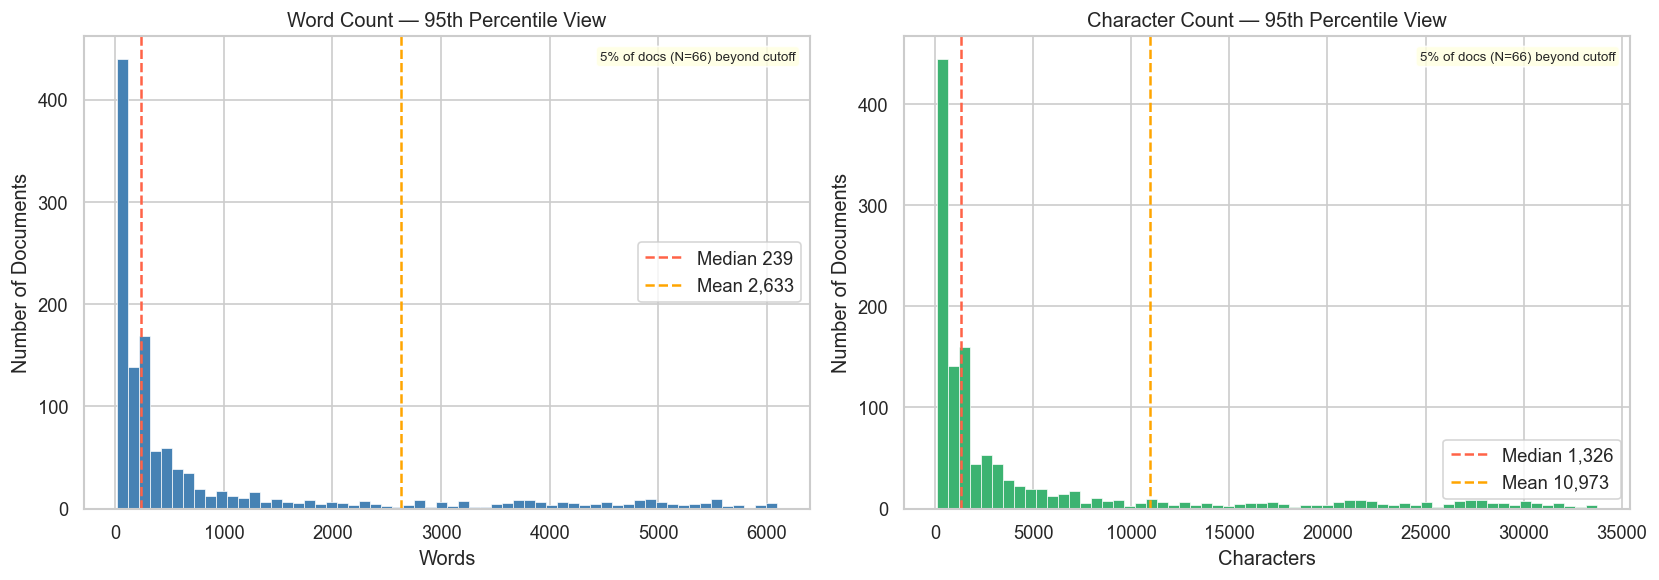

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

p95_words = meta["word_count"].quantile(0.95)
p95_chars = meta["char_count"].quantile(0.95)
n_beyond_words = int((meta["word_count"] > p95_words).sum())
n_beyond_chars = int((meta["char_count"] > p95_chars).sum())
wc_clipped = meta.loc[meta["word_count"] <= p95_words, "word_count"]
cc_clipped = meta.loc[meta["char_count"] <= p95_chars, "char_count"]

# Left — Word count clipped at P95
axes[0].hist(wc_clipped, bins=60, color="steelblue", edgecolor="white", linewidth=0.4)
axes[0].axvline(meta["word_count"].median(), color="tomato", linestyle="--", linewidth=1.5,
                label=f"Median {meta['word_count'].median():,.0f}")
axes[0].axvline(meta["word_count"].mean(), color="orange", linestyle="--", linewidth=1.5,
                label=f"Mean {meta['word_count'].mean():,.0f}")
axes[0].set_title("Word Count — 95th Percentile View")
axes[0].set_xlabel("Words")
axes[0].set_ylabel("Number of Documents")
axes[0].legend()
axes[0].text(0.98, 0.97,
             f"5% of docs (N={n_beyond_words}) beyond cutoff",
             transform=axes[0].transAxes,
             ha="right", va="top", fontsize=8,
             bbox=dict(boxstyle="round,pad=0.3", facecolor="lightyellow", alpha=0.8))

# Right — Char count clipped at P95
axes[1].hist(cc_clipped, bins=60, color="mediumseagreen", edgecolor="white", linewidth=0.4)
axes[1].axvline(meta["char_count"].median(), color="tomato", linestyle="--", linewidth=1.5,
                label=f"Median {meta['char_count'].median():,.0f}")
axes[1].axvline(meta["char_count"].mean(), color="orange", linestyle="--", linewidth=1.5,
                label=f"Mean {meta['char_count'].mean():,.0f}")
axes[1].set_title("Character Count — 95th Percentile View")
axes[1].set_xlabel("Characters")
axes[1].set_ylabel("Number of Documents")
axes[1].legend()
axes[1].text(0.98, 0.97,
             f"5% of docs (N={n_beyond_chars}) beyond cutoff",
             transform=axes[1].transAxes,
             ha="right", va="top", fontsize=8,
             bbox=dict(boxstyle="round,pad=0.3", facecolor="lightyellow", alpha=0.8))

plt.tight_layout()
plt.show()

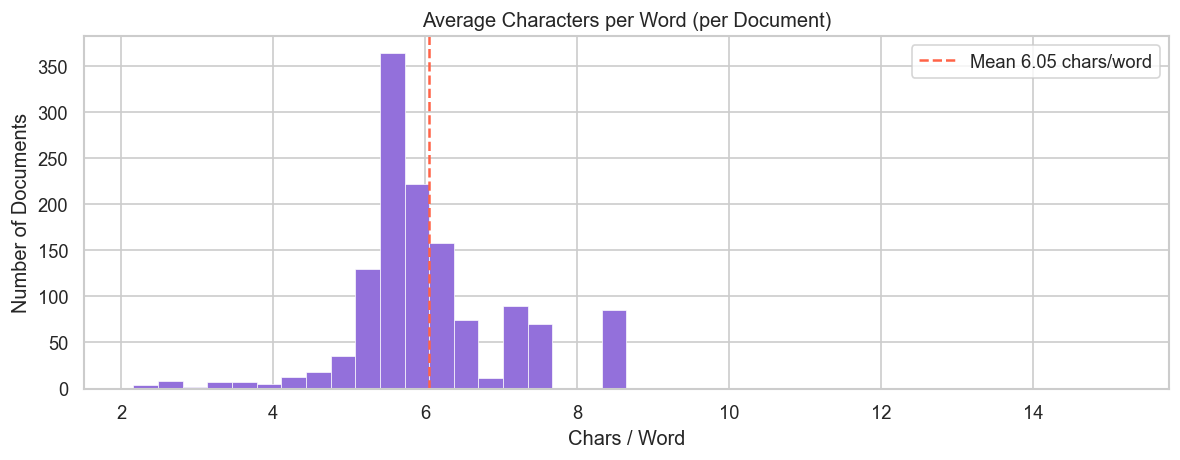

In [21]:
# Average characters per word (corpus-wide)
meta["chars_per_word"] = (meta["char_count"] / meta["word_count"].replace(0, np.nan)).round(2)

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(meta["chars_per_word"].dropna(), bins=40, color="mediumpurple", edgecolor="white", linewidth=0.4)
ax.axvline(meta["chars_per_word"].mean(), color="tomato", linestyle="--", linewidth=1.5,
           label=f"Mean {meta['chars_per_word'].mean():.2f} chars/word")
ax.set_title("Average Characters per Word (per Document)")
ax.set_xlabel("Chars / Word")
ax.set_ylabel("Number of Documents")
ax.legend()
plt.tight_layout()
plt.show()

---
## 4. Word Frequency Analysis

Reads all `.txt` files, tokenizes, filters Spanish stopwords (NLTK), and reports top-50 terms.

In [22]:
# Tokenize — keep alphabetic tokens (incl. accented Spanish chars), lowercase, min length 3
TOKEN_RE = re.compile(r"[a-záéíóúüñ]+", re.IGNORECASE)

all_tokens = []
for text in all_texts:
    tokens = TOKEN_RE.findall(text.lower())
    # Filter stopwords and very short tokens
    tokens = [t for t in tokens if t not in SPANISH_STOPWORDS and len(t) >= 3]
    all_tokens.extend(tokens)

print(f"Total tokens (after stopword filter): {len(all_tokens):,}")
print(f"Unique tokens: {len(set(all_tokens)):,}")

Total tokens (after stopword filter): 0
Unique tokens: 0


In [23]:
freq = Counter(all_tokens)
top50 = freq.most_common(50)

top50_df = pd.DataFrame(top50, columns=["word", "count"])
top50_df["pct_of_corpus"] = (top50_df["count"] / len(all_tokens) * 100).round(3)
print(top50_df.to_string(index=False))

Empty DataFrame
Columns: [word, count, pct_of_corpus]
Index: []


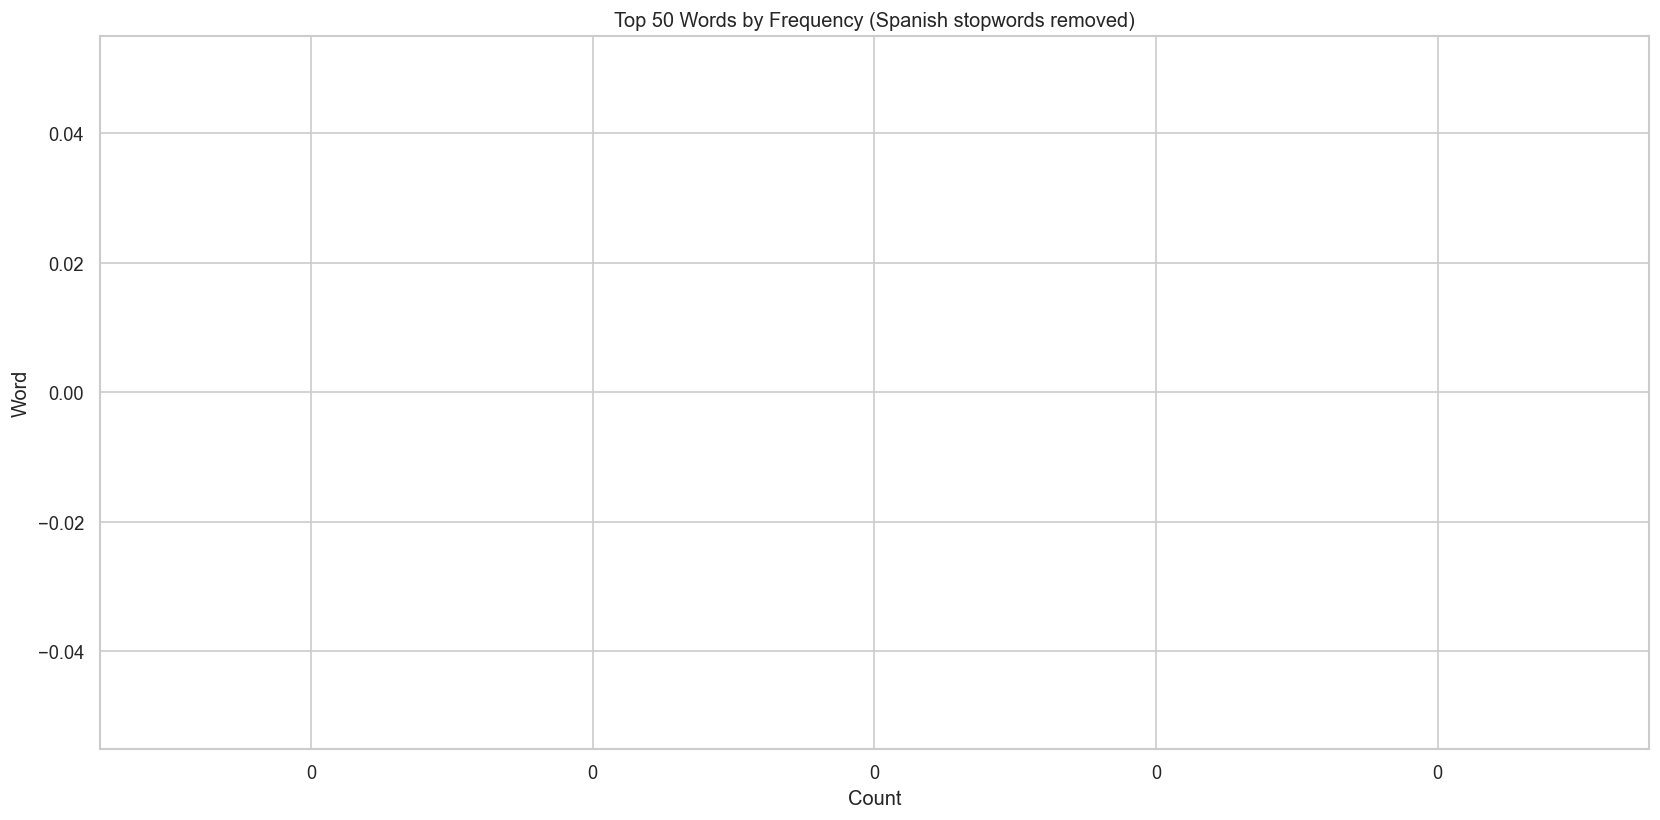

In [24]:
fig, ax = plt.subplots(figsize=(14, 7))
words = [w for w, _ in top50]
counts = [c for _, c in top50]

bars = ax.barh(words[::-1], counts[::-1], color="steelblue")
ax.bar_label(bars, fmt="{:,.0f}", padding=4, fontsize=8)
ax.set_title("Top 50 Words by Frequency (Spanish stopwords removed)")
ax.set_xlabel("Count")
ax.set_ylabel("Word")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.show()

---
## 5. TF-IDF Analysis

Each `.txt` file is treated as one document. `TfidfVectorizer` computes term scores with Spanish stopwords removed.  
We report the **top-30 terms by mean TF-IDF across the corpus** and show a heatmap over a document sample.

In [25]:
vectorizer = TfidfVectorizer(
    token_pattern=r"[a-záéíóúüñ]{3,}",  # Spanish-aware, min 3 chars
    stop_words=list(SPANISH_STOPWORDS),
    max_features=5000,
    sublinear_tf=True,  # log(tf+1) — reduces dominance of very frequent terms
)

tfidf_matrix = vectorizer.fit_transform(all_texts)  # shape: (n_docs, n_features)
feature_names = vectorizer.get_feature_names_out()

print(f"TF-IDF matrix shape: {tfidf_matrix.shape}")
print(f"Vocabulary size: {len(feature_names):,}")

ValueError: empty vocabulary; perhaps the documents only contain stop words

In [ ]:
# Mean TF-IDF per term across all documents
mean_tfidf = np.asarray(tfidf_matrix.mean(axis=0)).flatten()
top30_idx = mean_tfidf.argsort()[::-1][:30]

top30_terms = pd.DataFrame({
    "term": feature_names[top30_idx],
    "mean_tfidf": mean_tfidf[top30_idx].round(5),
})

print("Top 30 Terms by Mean TF-IDF")
print(top30_terms.to_string(index=False))

In [ ]:
fig, ax = plt.subplots(figsize=(13, 6))
sns.barplot(
    data=top30_terms,
    y="term",
    x="mean_tfidf",
    color="steelblue",
    ax=ax,
)
ax.set_title("Top 30 Terms by Mean TF-IDF (corpus-wide)")
ax.set_xlabel("Mean TF-IDF Score")
ax.set_ylabel("Term")
plt.tight_layout()
plt.show()

In [ ]:
# Heatmap: top-30 terms across a random sample of 40 documents
rng = np.random.default_rng(seed=42)
sample_idx = rng.choice(tfidf_matrix.shape[0], size=min(40, tfidf_matrix.shape[0]), replace=False)
sample_idx = np.sort(sample_idx)

heatmap_data = pd.DataFrame(
    tfidf_matrix[sample_idx][:, top30_idx].toarray(),
    columns=feature_names[top30_idx],
    index=[txt_files[i].stem[:30] for i in sample_idx],
)

fig, ax = plt.subplots(figsize=(16, 12))
sns.heatmap(
    heatmap_data,
    cmap="YlOrRd",
    linewidths=0.3,
    linecolor="white",
    ax=ax,
    cbar_kws={"label": "TF-IDF Score"},
)
ax.set_title("TF-IDF Heatmap — Top 30 Terms × 40 Random Documents")
ax.set_xlabel("Term")
ax.set_ylabel("Document")
ax.tick_params(axis="x", rotation=45)
ax.tick_params(axis="y", labelsize=7)
plt.tight_layout()
plt.show()

---
## 6. Data Quality Notes

Quick signals to assess corpus cleanliness and flag known issues.

In [ ]:
# Shortest and longest documents
meta_sorted_words = meta.sort_values("word_count")

print("10 Shortest Documents (by word count)")
print(meta_sorted_words[["filename", "word_count", "char_count"]].head(10).to_string(index=False))

print("\n10 Longest Documents (by word count)")
print(meta_sorted_words[["filename", "word_count", "char_count"]].tail(10).to_string(index=False))